# ============================================================
# SPOTIFY MUSIC & ARTIST ANALYSIS
# Web Scraping → Raw Dataset → Data Cleaning → EDA
# → Visualization → Insights
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 2. LOAD RAW DATASET
# ============================================================

In [2]:
df = pd.read_csv(r"C:\Users\Sankirth\Downloads\spotify tracks.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 114000
Columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# The dataset contains Spotify song information and audio features.
# These features can be used to study what characteristics are
# associated with popular songs.

# ============================================================
# 3. UNDERSTAND DATASET
# ============================================================

In [3]:
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


# The dataset contains song, artist, genre, popularity and
# different audio-related numerical columns.
# Missing values need to be handled before performing analysis.

# ============================================================
# 4. SELECT REQUIRED COLUMNS
# ============================================================

In [7]:
music_df = df[
    [
        "track_name",
        "artists",
        "album_name",
        "track_genre",
        "popularity",
        "duration_ms",
        "danceability",
        "energy",
        "loudness",
        "speechiness",
        "acousticness"
    ]
].copy()

In [8]:
music_df.head()

,track_name,artists,album_name,track_genre,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness
0,Comedy,Gen Hoshino,Comedy,acoustic,73,230666,0.676,0.4610,-6.746,0.1430,0.0322
1,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,149610,0.420,0.1660,-17.235,0.0763,0.9240
2,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,210826,0.438,0.3590,-9.734,0.0557,0.2100
3,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,201933,0.266,0.0596,-18.515,0.0363,0.9050
4,Hold On,Chord Overstreet,Hold On,acoustic,82,198853,0.618,0.4430,-9.681,0.0526,0.4690


# Only the columns needed for the Spotify music analysis
# are selected. This makes the dataset easier to work with.

# ============================================================
# 5. RENAME COLUMNS
# ============================================================

In [9]:
music_df.rename(
    columns={
        "track_name": "Song_Name",
        "artists": "Artist",
        "album_name": "Album",
        "track_genre": "Genre",
        "popularity": "Popularity",
        "duration_ms": "Duration_ms",
        "danceability": "Danceability",
        "energy": "Energy",
        "loudness": "Loudness",
        "speechiness": "Speechiness",
        "acousticness": "Acousticness"
    },
    inplace=True
)

music_df.head()

,Song_Name,Artist,Album,Genre,Popularity,Duration_ms,Danceability,Energy,Loudness,Speechiness,Acousticness
0,Comedy,Gen Hoshino,Comedy,acoustic,73,230666,0.676,0.4610,-6.746,0.1430,0.0322
1,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,149610,0.420,0.1660,-17.235,0.0763,0.9240
2,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,210826,0.438,0.3590,-9.734,0.0557,0.2100
3,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,201933,0.266,0.0596,-18.515,0.0363,0.9050
4,Hold On,Chord Overstreet,Hold On,acoustic,82,198853,0.618,0.4430,-9.681,0.0526,0.4690


# The column names are changed to simple and readable names
# so that the dataset is easier to understand.

# ============================================================
# 6. REMOVE DUPLICATE SONGS
# ============================================================

In [10]:
print("Duplicate rows:", music_df.duplicated().sum())

Duplicate rows: 582


In [11]:
music_df = music_df.drop_duplicates()

print("Rows after removing duplicates:", music_df.shape[0])

Rows after removing duplicates: 113418


# Duplicate records can affect the analysis by counting the same
# song more than once. Removing duplicates gives cleaner results.

# ============================================================
# 7. CHECK MISSING ARTISTS AND GENRES
# ============================================================

In [12]:
print("Missing artists:")
print(music_df["Artist"].isnull().sum())

print()

print("Missing genres:")
print(music_df["Genre"].isnull().sum())

Missing artists:
1

Missing genres:
0


# Missing artist and genre values can make artist and genre analysis
# incorrect, so these missing values need to be handled.

# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

In [13]:
music_df["Artist"] = music_df["Artist"].fillna("Unknown")

In [15]:
music_df["Genre"] = music_df["Genre"].fillna("Unknown")

In [16]:
music_df["Song_Name"] = music_df["Song_Name"].fillna("Unknown")

In [17]:
music_df["Album"] = music_df["Album"].fillna("Unknown")

In [18]:
print(music_df.isnull().sum())

Song_Name       0
Artist          0
Album           0
Genre           0
Popularity      0
Duration_ms     0
Danceability    0
Energy          0
Loudness        0
Speechiness     0
Acousticness    0
dtype: int64


# Missing text values are replaced with "Unknown" instead of
# deleting the complete row. This helps retain useful data.

# ============================================================
# 9. CONVERT SONG DURATION
# ============================================================

In [19]:
music_df["Duration_Minutes"] = music_df["Duration_ms"] / 60000

In [20]:
music_df["Duration_Minutes"] = music_df["Duration_Minutes"].round(2)

In [21]:
music_df[
    ["Song_Name", "Duration_ms", "Duration_Minutes"]
].head(10)

,Song_Name,Duration_ms,Duration_Minutes
0,Comedy,230666,3.84
1,Ghost - Acoustic,149610,2.49
2,To Begin Again,210826,3.51
3,Can't Help Falling In Love,201933,3.37
4,Hold On,198853,3.31
5,Days I Will Remember,214240,3.57
6,Say Something,229400,3.82
7,I'm Yours,242946,4.05
8,Lucky,189613,3.16
9,Hunger,205594,3.43


# Song duration was originally stored in milliseconds.
# It is converted into minutes because minutes are easier
# to understand when analyzing song length.

# ============================================================
# 10. REMOVE ORIGINAL DURATION COLUMN
# ============================================================

In [22]:
music_df = music_df.drop("Duration_ms", axis=1)

# The original duration column is removed because the converted
# Duration_Minutes column is easier to use.

# ============================================================
# 11. CHECK POPULARITY
# ============================================================

In [24]:
print(music_df["Popularity"].describe())

count    113418.000000
mean         33.359088
std          22.269800
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: Popularity, dtype: float64


In [25]:
print("Minimum popularity:", music_df["Popularity"].min())
print("Maximum popularity:", music_df["Popularity"].max())

Minimum popularity: 0
Maximum popularity: 100


# Popularity values are checked to understand the range of song
# popularity and to identify any unusual values.

# ============================================================
# 12. HANDLE EXTREME POPULARITY VALUES
# ============================================================

In [26]:
music_df = music_df[
    (music_df["Popularity"] >= 0) &
    (music_df["Popularity"] <= 100)
]

# Spotify popularity is expected to be between 0 and 100.
# Values outside this range are removed as invalid values.

# ============================================================
# 13. NORMALIZE DANCEABILITY
# ============================================================

In [27]:
music_df["Danceability_Normalized"] = (
    music_df["Danceability"] - music_df["Danceability"].min()
) / (
    music_df["Danceability"].max() - music_df["Danceability"].min()
)

# Danceability is normalized to a 0 to 1 scale.
# This makes numerical values easier to compare.

# ============================================================
# 14. NORMALIZE ENERGY
# ============================================================

In [29]:
music_df["Energy_Normalized"] = (
    music_df["Energy"] - music_df["Energy"].min()
) / (
    music_df["Energy"].max() - music_df["Energy"].min()
)

# Energy is also converted to a 0 to 1 scale so that it can
# be compared more easily with other numerical variables.

# ============================================================
# 15. NORMALIZE ACOUSTICNESS
# ============================================================

In [30]:
music_df["Acousticness_Normalized"] = (
    music_df["Acousticness"] - music_df["Acousticness"].min()
) / (
    music_df["Acousticness"].max() - music_df["Acousticness"].min()
)

# Acousticness is normalized to make the numerical values
# easier to compare.

In [31]:
music_df[
    [
        "Danceability",
        "Danceability_Normalized",
        "Energy",
        "Energy_Normalized"
    ]
].head()

,Danceability,Danceability_Normalized,Energy,Energy_Normalized
0,0.676,0.686294,0.4610,0.4610
1,0.420,0.426396,0.1660,0.1660
2,0.438,0.444670,0.3590,0.3590
3,0.266,0.270051,0.0596,0.0596
4,0.618,0.627411,0.4430,0.4430


In [32]:
print(music_df.isnull().sum())

Song_Name                  0
Artist                     0
Album                      0
Genre                      0
Popularity                 0
Danceability               0
Energy                     0
Loudness                   0
Speechiness                0
Acousticness               0
Duration_Minutes           0
Danceability_Normalized    0
Energy_Normalized          0
Acousticness_Normalized    0
dtype: int64


# ============================================================
# 16. FINAL DATA CHECK
# ============================================================

In [33]:
print("Final rows:", music_df.shape[0])
print("Final columns:", music_df.shape[1])

music_df.head()

Final rows: 113418
Final columns: 14


,Song_Name,Artist,Album,Genre,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Duration_Minutes,Danceability_Normalized,Energy_Normalized,Acousticness_Normalized
0,Comedy,Gen Hoshino,Comedy,acoustic,73,0.676,0.4610,-6.746,0.1430,0.0322,3.84,0.686294,0.4610,0.032329
1,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,0.420,0.1660,-17.235,0.0763,0.9240,2.49,0.426396,0.1660,0.927711
2,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,0.438,0.3590,-9.734,0.0557,0.2100,3.51,0.444670,0.3590,0.210843
3,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,0.266,0.0596,-18.515,0.0363,0.9050,3.37,0.270051,0.0596,0.908635
4,Hold On,Chord Overstreet,Hold On,acoustic,82,0.618,0.4430,-9.681,0.0526,0.4690,3.31,0.627411,0.4430,0.470884


# After cleaning, the dataset is ready for EDA and visualization.
# Duplicate and missing-value problems have been handled.

# ============================================================
# 17. SAVE CLEANED DATASET
# ============================================================

In [34]:
music_df.to_csv(
    "spotify_cleaned_dataset.csv",
    index=False
)

print("Cleaned Spotify dataset saved successfully")

Cleaned Spotify dataset saved successfully


# The cleaned dataset is saved separately so that the original
# raw dataset remains unchanged.

# ============================================================
# 18. MOST POPULAR ARTISTS
# ============================================================

In [35]:
artist_popularity = music_df.groupby("Artist")["Popularity"].mean()

artist_popularity = artist_popularity.sort_values(
    ascending=False
)

print(artist_popularity.head(10))

Artist
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Harry Styles                    92.0
Rema;Selena Gomez               92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: Popularity, dtype: float64


# The artists at the top have the highest average popularity
# in the dataset. These artists can be considered the most
# popular based on the available songs.

# ============================================================
# 19. TOP 10 ARTISTS BY POPULARITY
# ============================================================

In [36]:
top_artists = artist_popularity.head(10)

print(top_artists)

Artist
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Harry Styles                    92.0
Rema;Selena Gomez               92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: Popularity, dtype: float64


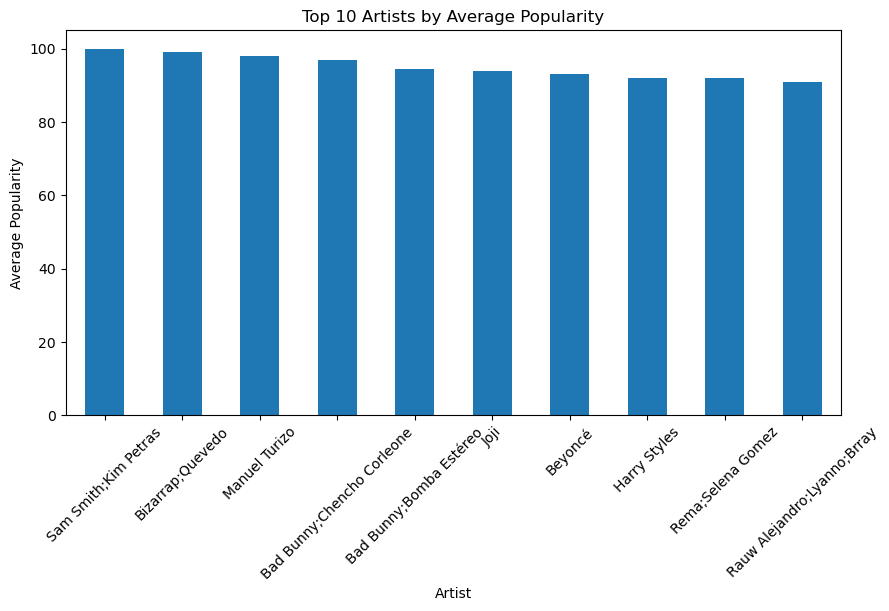

In [37]:
plt.figure(figsize=(10, 5))

top_artists.plot(kind="bar")

plt.xlabel("Artist")
plt.ylabel("Average Popularity")
plt.title("Top 10 Artists by Average Popularity")

plt.xticks(rotation=45)

plt.show()

# This graph compares the average popularity of the top 10 artists.
# Taller bars represent artists whose songs have higher average
# popularity.

# ============================================================
# 20. SONG DURATION VS POPULARITY
# ============================================================

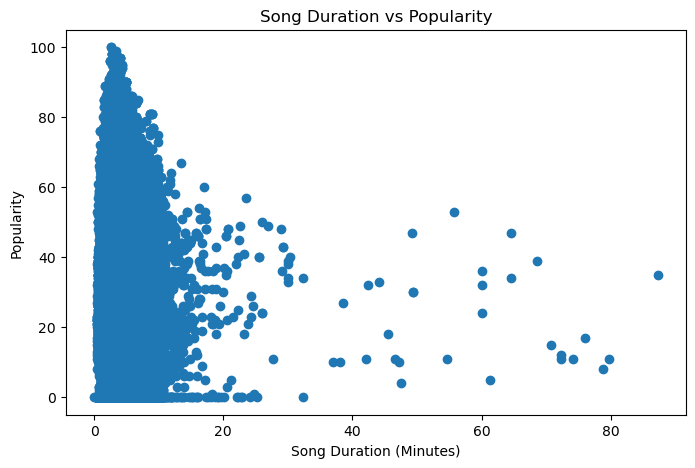

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(
    music_df["Duration_Minutes"],
    music_df["Popularity"]
)

plt.xlabel("Song Duration (Minutes)")
plt.ylabel("Popularity")
plt.title("Song Duration vs Popularity")

plt.show()

In [40]:
print(
    music_df[
        ["Duration_Minutes", "Popularity"]
    ].corr()
)

                  Duration_Minutes  Popularity
Duration_Minutes          1.000000   -0.008207
Popularity               -0.008207    1.000000


# The scatter plot shows whether song length is related to popularity.
# If the points are widely scattered, song duration may not have
# a strong relationship with popularity.

# ============================================================
# 21. DANCEABILITY VS POPULARITY
# ============================================================

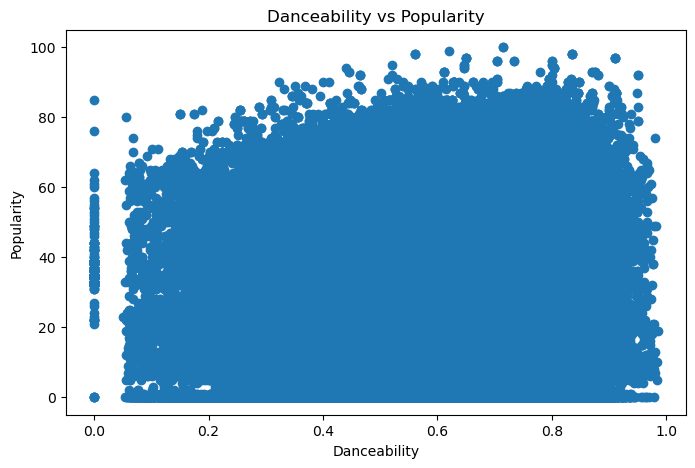

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    music_df["Danceability"],
    music_df["Popularity"]
)

plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Danceability vs Popularity")

plt.show()

# This graph helps us understand whether more danceable songs
# tend to have higher popularity.
# A positive correlation means popularity tends to increase
# as danceability increases.

# ============================================================
# 22. ENERGY VS POPULARITY
# ============================================================

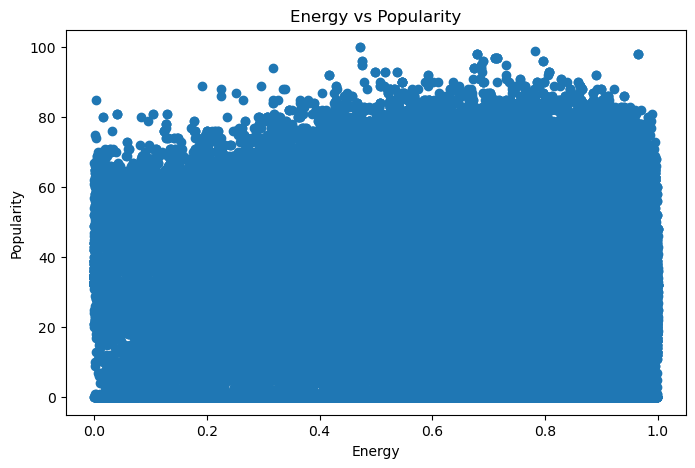

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(
    music_df["Energy"],
    music_df["Popularity"]
)

plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy vs Popularity")

plt.show()

# This graph checks whether energetic songs are more popular.
# A positive correlation means higher energy is associated with
# higher popularity.

# ============================================================
# 23. GENRES THAT DOMINATE
# ============================================================

In [43]:
genre_count = music_df["Genre"].value_counts()

print(genre_count.head(10))

Genre
acoustic      1000
spanish       1000
electronic    1000
reggaeton     1000
mandopop      1000
sad           1000
samba         1000
sertanejo     1000
sleep         1000
ska           1000
Name: count, dtype: int64


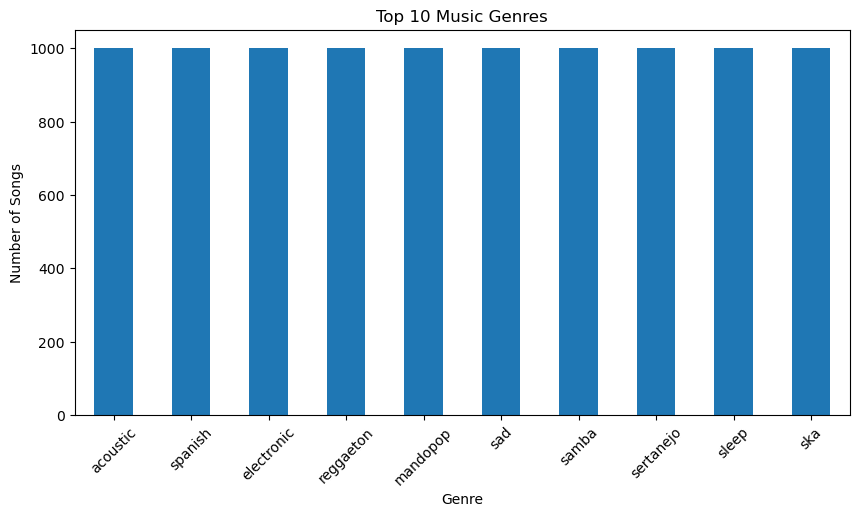

In [44]:
plt.figure(figsize=(10, 5))

genre_count.head(10).plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.title("Top 10 Music Genres")

plt.xticks(rotation=45)

plt.show()

# The genres with the tallest bars have the largest number of
# songs in the dataset. These are the dominant genres based
# on the number of available songs.

# ============================================================
# 24. AVERAGE POPULARITY BY GENRE
# ============================================================

In [45]:
genre_popularity = music_df.groupby("Genre")["Popularity"].mean()

genre_popularity = genre_popularity.sort_values(
    ascending=False
)

print(genre_popularity.head(10))

Genre
pop-film     59.280280
k-pop        56.906907
chill        53.704705
sad          52.379000
grunge       49.632265
indian       49.528056
anime        48.766767
emo          48.224449
pop          47.997982
sertanejo    47.866000
Name: Popularity, dtype: float64


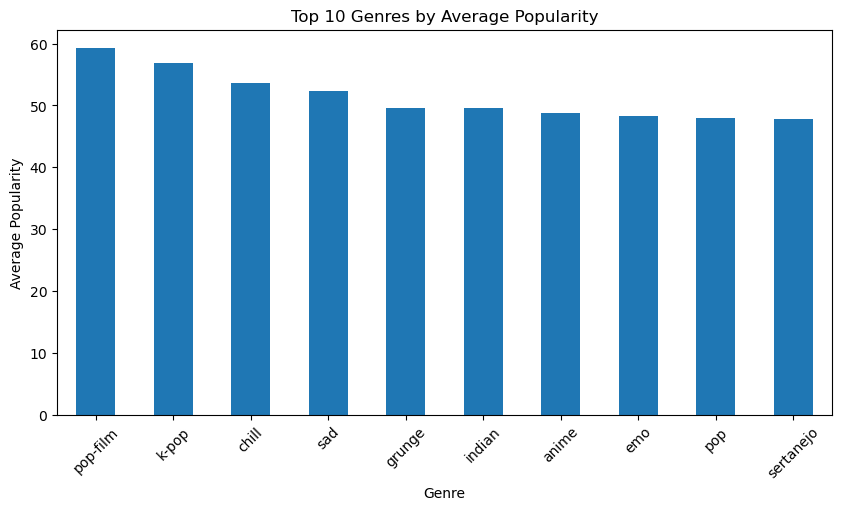

In [46]:
plt.figure(figsize=(10, 5))

genre_popularity.head(10).plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.title("Top 10 Genres by Average Popularity")

plt.xticks(rotation=45)

plt.show()

# This graph identifies genres with the highest average popularity.
# A genre having many songs does not always mean that it has the
# highest average popularity.

# ============================================================
# 25. POPULARITY DISTRIBUTION
# ============================================================

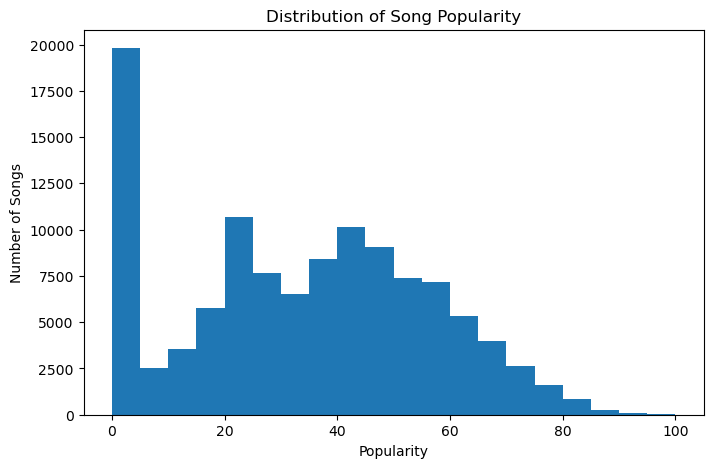

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(
    music_df["Popularity"],
    bins=20
)

plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.title("Distribution of Song Popularity")

plt.show()

# The histogram shows how songs are distributed across different
# popularity levels. It helps us understand whether most songs
# have low, medium or high popularity.

# ============================================================
# 26. DANCEABILITY DISTRIBUTION
# ============================================================

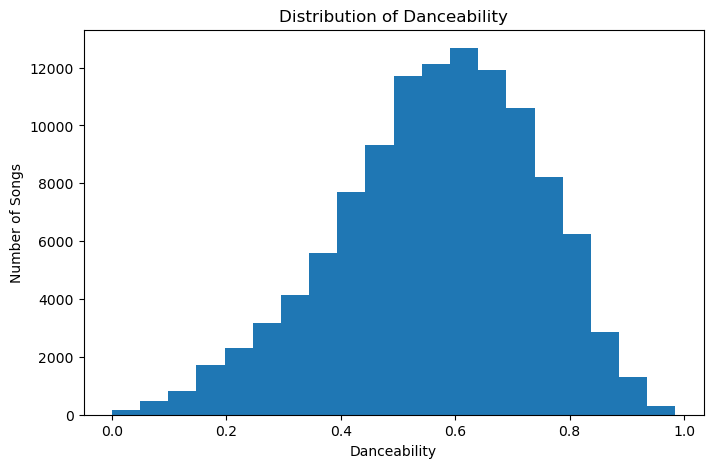

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    music_df["Danceability"],
    bins=20
)

plt.xlabel("Danceability")
plt.ylabel("Number of Songs")
plt.title("Distribution of Danceability")

plt.show()

# The graph shows the common danceability levels of songs.
# It helps us understand whether the dataset contains mostly
# less danceable or highly danceable songs.

# ============================================================
# 27. ENERGY DISTRIBUTION
# ============================================================

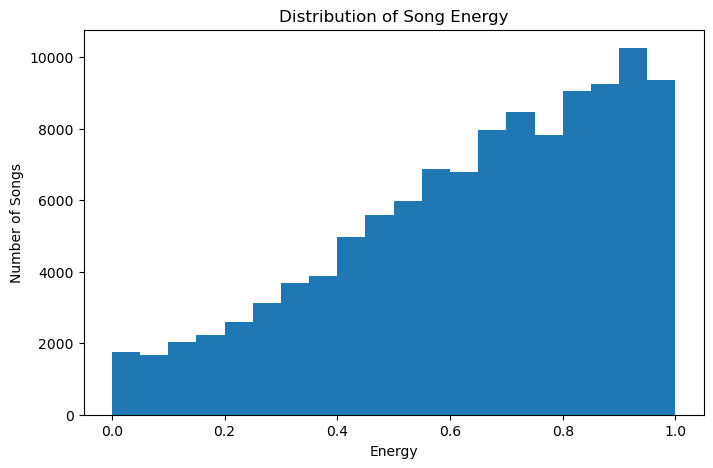

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(
    music_df["Energy"],
    bins=20
)

plt.xlabel("Energy")
plt.ylabel("Number of Songs")
plt.title("Distribution of Song Energy")

plt.show()

# The graph shows the energy levels of songs.
# It helps identify whether the dataset mainly contains
# low-energy, medium-energy or high-energy songs.

# ============================================================
# 28. SONG DURATION DISTRIBUTION
# ============================================================

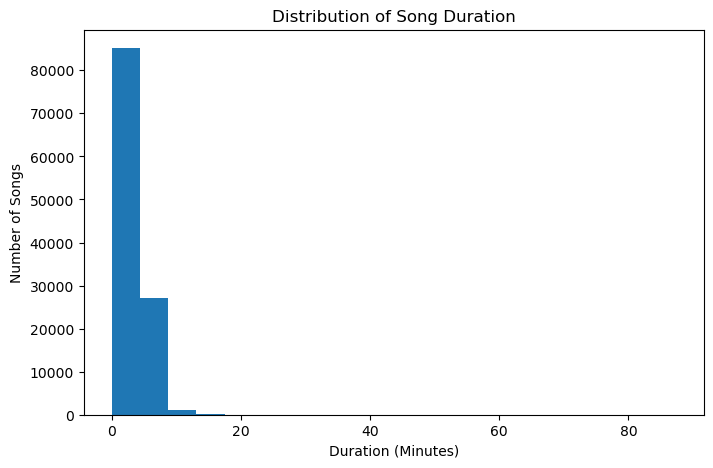

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(
    music_df["Duration_Minutes"],
    bins=20
)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")
plt.title("Distribution of Song Duration")

plt.show()

# This graph shows the most common song lengths in the dataset.
# It helps us understand the typical duration of songs.

# ============================================================
# 29. CORRELATION BETWEEN MUSIC FEATURES
# ============================================================

In [51]:
correlation = music_df[
    [
        "Popularity",
        "Duration_Minutes",
        "Danceability",
        "Energy",
        "Loudness",
        "Speechiness",
        "Acousticness"
    ]
].corr()

print(correlation)

                  Popularity  Duration_Minutes  Danceability    Energy  \
Popularity          1.000000         -0.008207      0.033789 -0.002968   
Duration_Minutes   -0.008207          1.000000     -0.074224  0.058300   
Danceability        0.033789         -0.074224      1.000000  0.131459   
Energy             -0.002968          0.058300      0.131459  1.000000   
Loudness            0.047258         -0.004070      0.256460  0.760550   
Speechiness        -0.045814         -0.063177      0.108019  0.141881   
Acousticness       -0.022439         -0.103856     -0.169156 -0.732793   

                  Loudness  Speechiness  Acousticness  
Popularity        0.047258    -0.045814     -0.022439  
Duration_Minutes -0.004070    -0.063177     -0.103856  
Danceability      0.256460     0.108019     -0.169156  
Energy            0.760550     0.141881     -0.732793  
Loudness          1.000000     0.059976     -0.588070  
Speechiness       0.059976     1.000000     -0.001260  
Acousticness   

# ============================================================
# 30. MOST POPULAR SONGS
# ============================================================

In [53]:
popular_songs = music_df.sort_values(
    "Popularity",
    ascending=False
)

popular_songs[
    [
        "Song_Name",
        "Artist",
        "Genre",
        "Popularity"
    ]
].head(20)

,Song_Name,Artist,Genre,Popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
67356,La Bachata,Manuel Turizo,latin,98
88410,La Bachata,Manuel Turizo,reggae,98
89411,La Bachata,Manuel Turizo,reggaeton,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98
68303,La Bachata,Manuel Turizo,latino,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98


# These are the songs with the highest popularity scores
# in the dataset. They can be studied to understand common
# characteristics of highly popular songs.

# ============================================================
# 31. ARTISTS WITH MOST SONGS
# ============================================================

In [54]:
artist_song_count = music_df["Artist"].value_counts()

print(artist_song_count.head(10))

Artist
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    182
OneRepublic        181
Name: count, dtype: int64


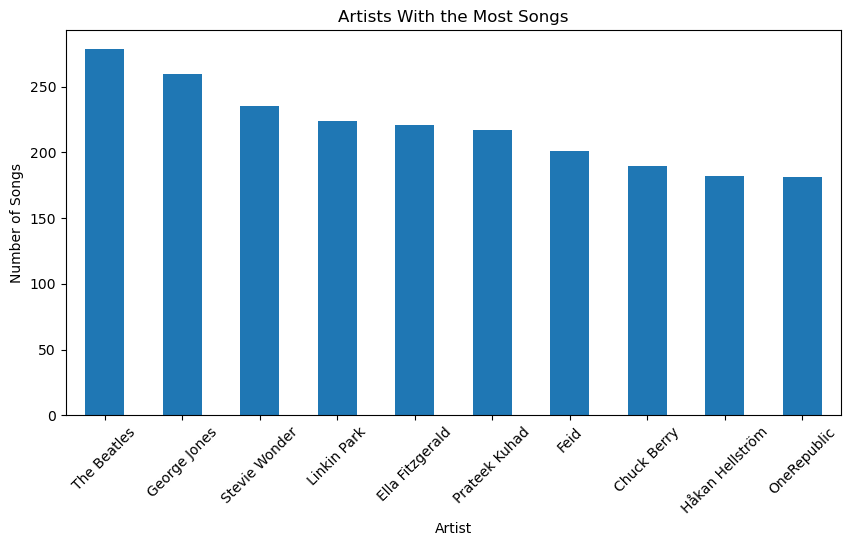

In [55]:
plt.figure(figsize=(10, 5))

artist_song_count.head(10).plot(kind="bar")

plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.title("Artists With the Most Songs")

plt.xticks(rotation=45)

plt.show()

# The artists with the highest bars have the largest number
# of songs in the dataset. Having many songs does not necessarily
# mean that the artist has the highest average popularity.